# Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


> The dataset contains 7043 customers and 21 features. The target variable is Churn.

##### Check Class Imbalance

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

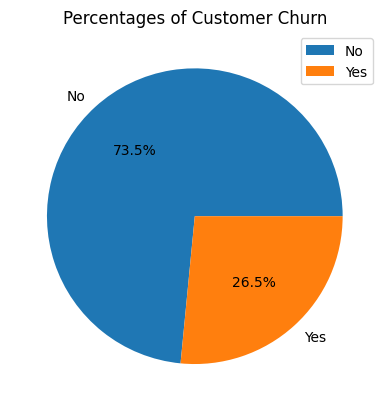

In [26]:
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Percentages of Customer Churn")
plt.ylabel('')
plt.legend()
plt.show()

> The dataset is imbalanced, so accuracy alone is not reliable. Should consider it may require to apply sampling methods.

# Correlation / Churn Analysis

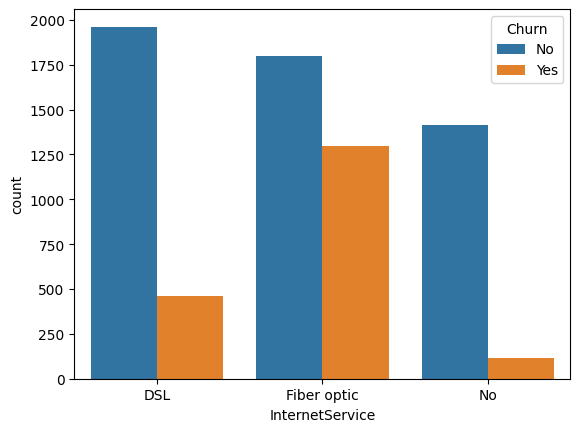

In [9]:
# InternetService

sns.countplot(df, x='InternetService', hue='Churn')
plt.show()

> By the above plot, customer with Fiber optic are more likely to churn than DSL and other users.

> Therefore, there is a significant relationship between the customer’s internet service provider and their likelihood to churn.

---

**Customers' Demographic Vs. Churn**

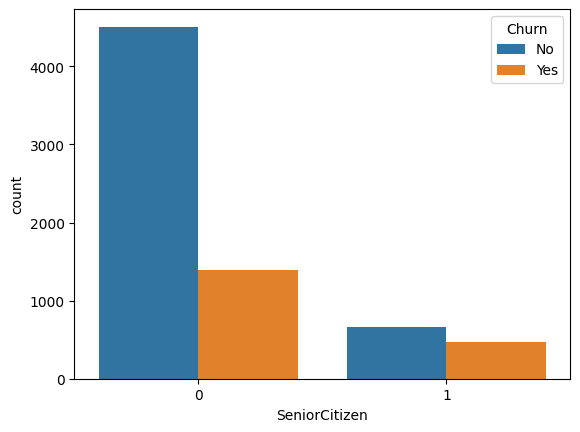

In [28]:
# Churn Vs. SeniorCitizen

sns.countplot(df, x='SeniorCitizen', hue='Churn')
plt.show()

> Senior citizens are less likely to churn compared to non-senior citizens

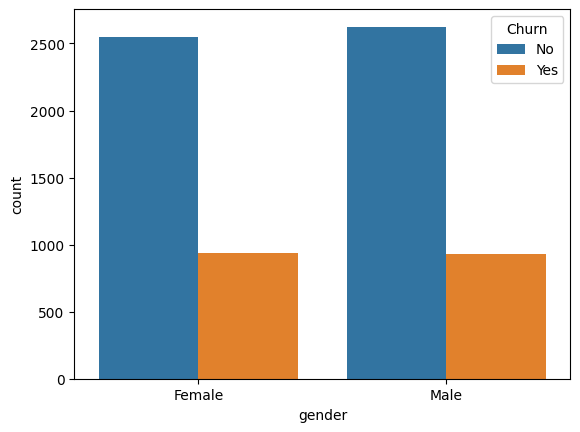

In [10]:
# Churn / gender

sns.countplot(df, x='gender', hue='Churn')
plt.show()

> Similar pattern, not much difference in gender type in terms of Churn rate.

> There is no significant difference in churn rates between male and female customers.

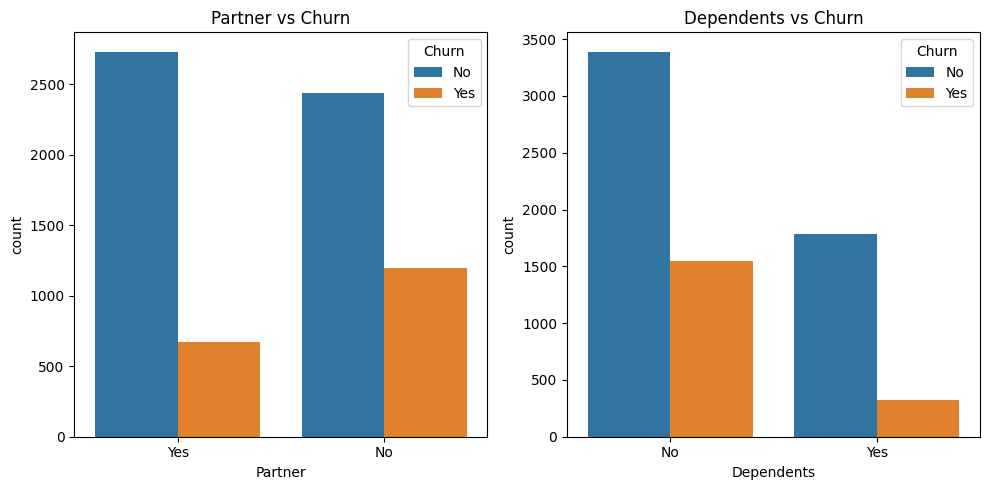

In [13]:
# Subplots

fig, ax = plt.subplots(1, 2, figsize=(10,5))

# Partner vs Churn
sns.countplot(df, x="Partner", hue="Churn", ax=ax[0])
ax[0].set_title("Partner vs Churn")

# Dependents vs Churn
sns.countplot(df, x="Dependents", hue="Churn", ax=ax[1])
ax[1].set_title("Dependents vs Churn")

plt.tight_layout()
plt.show()

> People without partner could have more churn rate while 

> Those with dependents have lower churn.

> Hence, it is notable that single people have higher chance to churn.

---

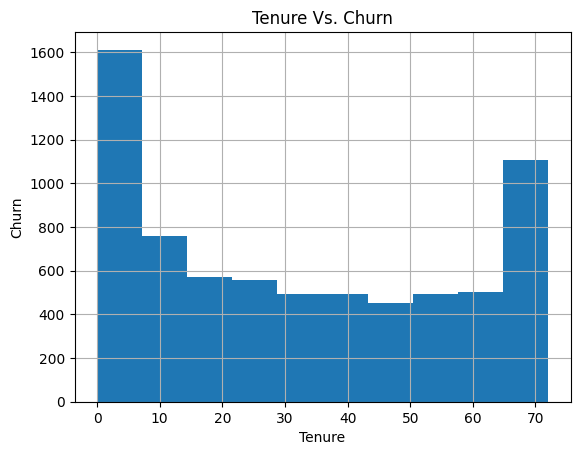

In [11]:
# tenure vs. churn

df['tenure'].hist()
plt.title('Tenure Vs. Churn')
plt.xlabel('Tenure')
plt.ylabel('Churn')
plt.show()

> According to the histogram of 'tenure', Customers with shorter tenure tend to churn more. 

> Moreover, it also makes sense in the real world since the longer customer has stayed with the company, the less chance they leave.

Text(0, 0.5, 'Churn Count')

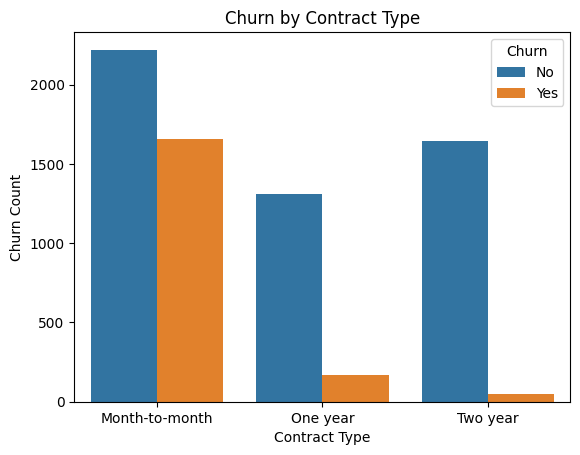

In [12]:
# Churn vs. Contract

sns.countplot(df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Count')

> There is a positive correlation between higher contract terms and retention rate as people with month-to-month contracts churn more.

> And it could be stated that the longer the contract, the less chance for customers to churn.

> Hence, customer retention can be improved by offering longer contract terms.


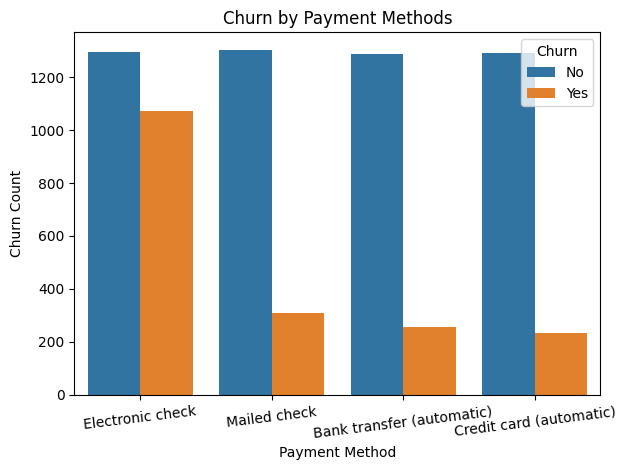

In [14]:
# Payment Method and Churn

sns.countplot(df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=7)
plt.title('Churn by Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Churn Count')
plt.tight_layout()

> Obviously, people with Electronic check have more churn than other payment types (Mailed check, Bank transfer, Credit card)

In [15]:
# Churn Vs. Montly Charges

df['MonthlyCharges'].dtype

dtype('float64')

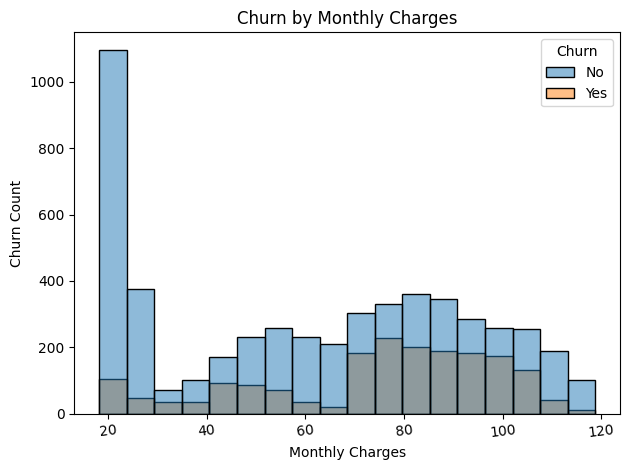

In [16]:
# Churn Vs. Montly Charges

sns.histplot(df, x='MonthlyCharges', hue='Churn')
plt.xticks(rotation=7)
plt.title('Churn by Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Count')
plt.tight_layout()

> Accordingly, higher monthly charges correlate with customer churn.

---

# Summary Analysis

The dataset contains 7043 customers and 21 features, with Churn as the target variable.

The dataset is imbalanced so that accuracy alone may not be a reliable evaluation metric, consider techniques such as sampling methods or confusion matrix.

Based on the **internet service** analysis, customers using Fiber optic services are more likely to churn compared to those using DSL or other services. This suggests a significant relationship between the type of internet service and customer churn behavior.

**Demographic**

- Senior citizens appear less likely to churn compared to non-senior citizens, indicating that age group may influence customer retention.

- Gender does not show a meaningful impact on churn, as both male and female customers exhibit similar churn patterns.

- Customers without partners nor depedents tend to have a higher churn rate. This suggests that single individuals may be more likely to leave the service.



From the **tenure** distribution, customers with shorter tenure are more likely to churn, while those who have stayed longer with the company tend to remain. This reflects the reality: the longer a customer stays, the lower the likelihood of leaving.

**Contract type** strongly influences churn behavior. Customers with month-to-month contracts churn more frequently, while longer contract terms are associated with higher retention rates. Hence, customer retention can be improved by offering longer contract terms.

Regarding **payment methods**, customers who use electronic-checks have a higher churn rate compared to other payment types such as mailed checks, bank transfers, or credit cards.

Additionally, **higher monthly charges** appear to correlate with higher churn rates, suggesting that pricing may influence customer decisions to remain with the service.

---